With larger receptive fields, increasingly abstract semantic representations of the data can be learned at the cost of sacrificing localization
precision. Layers in the decoder double spatial dimensions while halving feature sizes. This allows the network to localize the semantic
reprsentation at increasingly larger spatial dimensions. Corresponding layers in the encoder are cropped and concatenated to the upsampled layers
in the decoder in order to reintroduce most of the fine spatial information that was preserved in the encoder. Subsequent convolutions learn how
the fine spatial information and the coarse semantic information can be combined effectively. The concatenation also gives layer inputs multiple
shorter paths to reach the output, helping information flow through the network. All of these design decisions result in the encoder learning
*what* is in the data and the decoder learning *where* it is spatially.

Each label corresponds to its own channel, so the final layer in the model uses a 1x1 convolution to map the 64 output channels to the target
number of channels. Softmax is applied per pixel, summing across channels. Cross entropy loss is used as the loss function. Each pixel is
chosen from the channel that coressponds to the pixel's true label.

$E = \sum_{x \in \Omega} w(\mathbf{x}) log(p_{l(x)}(\mathbf(x)))$

Our implementation of the model will differ from the original in several ways.
1. We will use zero-padding so that the output size matches the input size. Border pixels are relatively insignificant, so the slight performance
   decrease from introducing a small amount of extra information should be negligible. Zero padding would also make training and inference much simpler.
2. Ditching the overlap tile strategy in favor of segmenting the entire image, regardless of size. Modern GPUs should be able to hand it.
4. Replace each convolution + ReLU with convolution + normalization layer.
5. No elastic deformation, just basic data augmentation.

In [7]:
%matplotlib inline

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchmetrics.classification import MulticlassJaccardIndex
from torchvision.transforms import v2
import torchvision.tv_tensors as tv_tensors

from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display

# Map "id" to "trainId"
# https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py
bg = 255
mapping = torch.full((256,), bg, dtype=torch.long)
mapping[7]  = 0   # road
mapping[8]  = 1   # sidewalk
mapping[11] = 2   # building
mapping[12] = 3   # wall
mapping[13] = 4   # fence
mapping[17] = 5   # pole
mapping[19] = 6   # traffic light
mapping[20] = 7   # traffic sign
mapping[21] = 8   # vegetation
mapping[22] = 9   # terrain
mapping[23] = 10  # sky
mapping[24] = 11  # person
mapping[25] = 12  # rider
mapping[26] = 13  # car
mapping[27] = 14  # truck
mapping[28] = 15  # bus
mapping[31] = 16  # train
mapping[32] = 17  # motorcycle
mapping[33] = 18  # bicycle

In [ ]:
class CityscapesDataset(Dataset):
    def __init__(self, target_width, img_folder, label_folder, is_train=False):
        super().__init__()
        self.img_paths = []
        self.label_paths = []
        self.is_train = is_train

        for p in Path(img_folder).iterdir():
            if not p.is_file():
                continue
            base = p.stem.split("_leftImg8bit")[0]
            self.img_paths.append(p)
            self.label_paths.append(f"{label_folder}/{base}_gtFine_labelIds.png")

        # Resize while preserving the aspect ratio and convert PIL image to tensor
        self.base_transforms = v2.Compose([
            v2.Resize(size=(target_width, int(1024 * target_width / 2048))),
            v2.ToImage(),
        ])

        self.spatial_augmentations = v2.Compose([ v2.RandomHorizontalFlip(p=0.5) ])

        # Color jitter and ImageNet normalization
        self.image_only_transforms = v2.Compose([
            v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with Image.open(self.img_paths[idx]) as img, Image.open(self.label_paths[idx]) as mask:
            mask_tensor = tv_tensors.Mask(mask) # Mark this as a segmentation mask
            img_tensor, mask_tensor = self.base_transforms(img, mask_tensor)

            if self.is_train:
                img_tensor, mask_tensor = self.spatial_augmentations(img_tensor, mask_tensor)

            # Map ids to labels the model will predict
            label_tensor = mask_tensor[0].long() # All channels contain the same value
            label_tensor = mapping[label_tensor]
            img_tensor = self.image_only_transforms(img_tensor)

        return img_tensor, label_tensor

In [9]:
class UNet(nn.Module):
    def __init__(self, num_labels):
        super().__init__()

        self.layers = nn.ModuleList([])
        in_channels, out_channels, stages = 3, 64, 5

        # Encoder
        for i in range(stages):
            if i != 0:
                self.layers.append(nn.MaxPool2d(2, 2))

            self.layers.extend([
                nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1),
                nn.BatchNorm2d(out_channels), # since there is currently a batch size of 4
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU()
            ])

            in_channels = out_channels
            out_channels *= 2

        # Decoder
        for i in range(stages - 1):
            out_channels = in_channels
            in_channels = int(in_channels / 2)

            self.layers.extend([
                nn.ConvTranspose2d(out_channels, in_channels, 2, stride=2),
                nn.Conv2d(out_channels, in_channels, 3, stride=1, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(),
                nn.Conv2d(in_channels, in_channels, 3, stride=1, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU()
            ])

        self.layers.append(nn.Conv2d(in_channels, num_labels, 1, stride=1))

    def forward(self, x):
        feature_maps = []
        for layer in self.layers:
            if isinstance(layer, nn.MaxPool2d):
                feature_maps.append(x)
            x = layer(x)
            if isinstance(layer, nn.ConvTranspose2d):
                prev_map = feature_maps.pop()
                prev_map = v2.functional.center_crop(prev_map, output_size=[x.shape[2], x.shape[3]])
                x = torch.cat((prev_map, x), dim=1)
        return x

In [ ]:
def plot_stats(fig, axs, errors=None, losses=None):
    clear_output(wait=True)
    for ax in axs:
        ax.clear()
    ax_loss, ax_error = axs[0], axs[1]

    if losses is not None and len(losses) > 0:
        ax_loss.plot(losses, "b-")
        ax_loss.autoscale_view(scalex=True, scaley=True)
        ax_loss.set_title(f"Mean Validation Loss: {losses[-1]:.2f}")
        ax_loss.set_xlabel("Iterations")
        ax_loss.set_ylabel("Loss")

    if errors is not None and len(errors) > 0:
        ax_error.plot(errors, "r-")
        ax_error.autoscale_view(scalex=True, scaley=True)
        ax_error.set_title(f"Mean Validation Error {errors[-1]:.2f}")
        ax_error.set_xlabel("Iterations")
        ax_error.set_ylabel("Error")

    fig.tight_layout() # Prevents overlapping labels
    display.display(fig)

In [ ]:
def run_model(model, criterion, loader, optimizer, device, jaccard_metric=None, training=False):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, total_error = 0, 0
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for _, (imgs, segmentation_map) in enumerate(loader):
            imgs = imgs.to(device, non_blocking=True)
            segmentation_map = segmentation_map.to(device, non_blocking=True)

            prediction = model(imgs)
            loss = criterion(prediction, segmentation_map)
            total_loss += loss.item()

            if jaccard_metric is not None:
                # Each pixel (grayscale) is the index of the channel with the highest value at its position
                # (batch size, classes, height, width) -> (batch size, height, width)
                predicted_classes = torch.argmax(prediction.detach(), dim=1)
                # Compute the Intersection over Union
                iou = jaccard_metric(predicted_classes, segmentation_map).item()
                total_error += (100 - 100 * iou)

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

    return total_loss, total_error

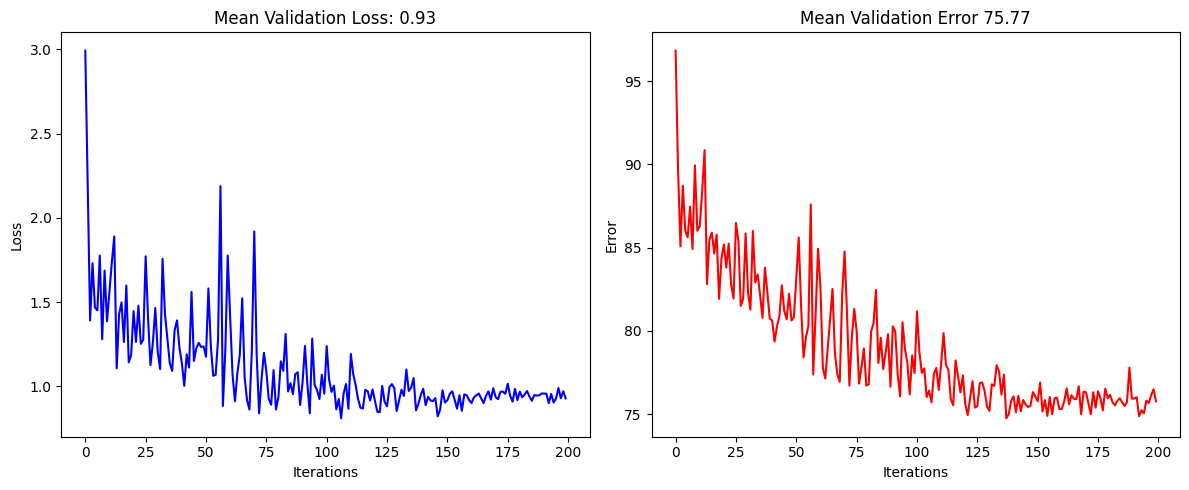

Started testing...
Mean inference error: nan


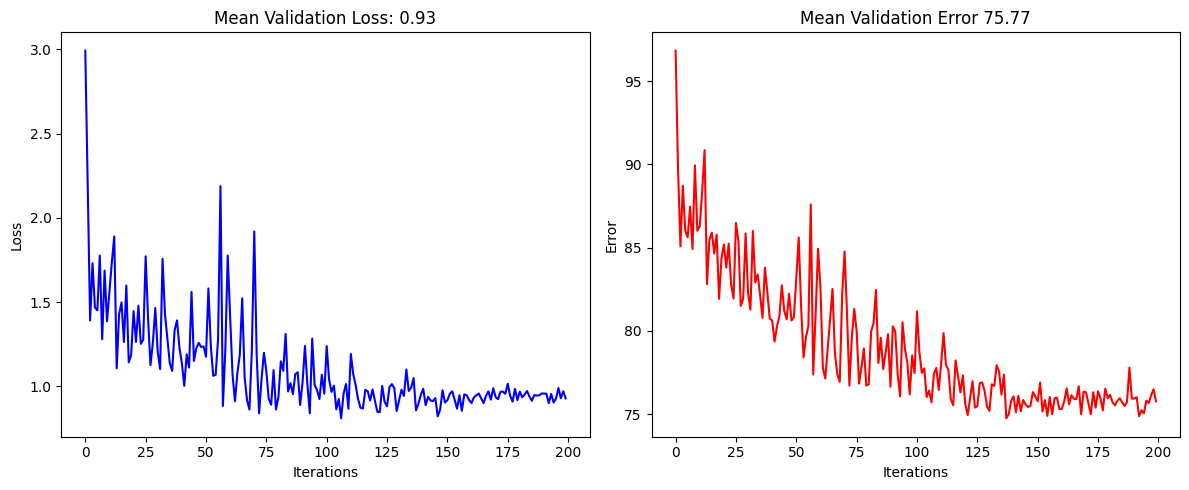

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

model = UNet(19).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=bg)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Used for computing mIoU
jaccard_metric = MulticlassJaccardIndex(
    num_classes=19,
    ignore_index=bg,
    average="macro"
).to(device)

batch_size, epochs, img_width = 8, 200, 512
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

losses, errors = [], []
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

train_samples = CityscapesDataset(
    img_width,
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Cityscape Dataset/leftImg8bit/train/zurich",
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Fine Annotations/gtFine/train/zurich",
    is_train=True
)
train_loader = DataLoader(dataset=train_samples, batch_size=batch_size, shuffle=True, num_workers=2)

val_samples = CityscapesDataset(
    img_width,
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Cityscape Dataset/leftImg8bit/val/lindau",
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Fine Annotations/gtFine/val/lindau",
)
val_loader = DataLoader(dataset=val_samples, batch_size=batch_size, shuffle=True, num_workers=2)

test_samples = CityscapesDataset(
    img_width,
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Cityscape Dataset/leftImg8bit/test/berlin",
    "/kaggle/input/datasets/electraawais/cityscape-dataset/Fine Annotations/gtFine/test/berlin",
)
test_loader = DataLoader(dataset=test_samples, batch_size=1, shuffle=True, num_workers=2)

print("Started training...")
for epoch in range(epochs):
    print(f"Epoch {epoch}/{epochs}")

    # Train
    run_model(model, criterion, train_loader, optimizer, device, training=True)

    # Validate
    total_loss, total_error = run_model(model, criterion, val_loader,
                                        optimizer, device, jaccard_metric=jaccard_metric)

    losses.append(total_loss / len(val_loader))
    errors.append(total_error / len(val_loader))
    plot_stats(fig, axs, errors=errors, losses=losses)
    scheduler.step()

# Test model
print("Started testing...")
_, total_error = run_model(model, criterion, test_loader, optimizer, device, jaccard_metric=jaccard_metric)
print("Mean inference error:", total_error / len(test_loader))